In [8]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
DATA_DIR = 'data'
MODEL_SAVE_PATH = 'gesture_lstm.pth'
MAX_SEQ_LENGTH = 10
INPUT_SIZE = 21 * 3 
HIDDEN_SIZE = 64
NUM_LAYERS = 2
NUM_CLASSES = 10   
BATCH_SIZE = 16
LEARNING_RATE = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [10]:
class GestureDataset(Dataset):
    def __init__(self, data_dir, max_seq_length):
        self.data = []
        self.labels = []
        
        for class_name in os.listdir(data_dir):
            class_dir = os.path.join(data_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
                
            label = int(class_name)
            
            for file in os.listdir(class_dir):
                if file.endswith('.json'):
                    file_path = os.path.join(class_dir, file)
                    with open(file_path, 'r') as f:
                        frames = json.load(f)
                    
                    if not frames:
                        continue
                        
                    sequence = []
                    for frame in frames:
                        frame_features = []
                        for lm in frame:
                            frame_features.extend([lm['x'], lm['y'], lm['z']])
                        sequence.append(frame_features)
                    
                    seq_array = np.array(sequence)
                    seq_len = len(seq_array)
                    
                    if seq_len > max_seq_length:
                        seq_array = seq_array[:max_seq_length]
                        
                    elif seq_len < max_seq_length:
                        pad_len = max_seq_length - seq_len
                        last_frame = seq_array[-1]  
                        padding = np.tile(last_frame, (pad_len, 1)) 
                        seq_array = np.vstack((seq_array, padding))
                        
                    self.data.append(seq_array)
                    self.labels.append(label)

        self.data = torch.tensor(np.array(self.data), dtype=torch.float32)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [11]:
class GestureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(GestureLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        
        out = out[:, -1, :] 
        out = self.fc(out)
        return out

In [12]:
dataset = GestureDataset(DATA_DIR, MAX_SEQ_LENGTH)

In [13]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = GestureLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [15]:
EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for sequences, labels in train_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}')

Epoch [5/50], Loss: 0.0011
Epoch [10/50], Loss: 0.0012
Epoch [15/50], Loss: 0.0008
Epoch [20/50], Loss: 0.0008
Epoch [25/50], Loss: 0.0007
Epoch [30/50], Loss: 0.0007
Epoch [35/50], Loss: 0.0006
Epoch [40/50], Loss: 0.0006
Epoch [45/50], Loss: 0.0005
Epoch [50/50], Loss: 0.0005


In [16]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to gesture_lstm.pth


Test Accuracy: 93.98%

Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.88      0.88         8
           2       1.00      1.00      1.00         7
           3       0.90      0.90      0.90        10
           4       0.89      1.00      0.94         8
           5       1.00      1.00      1.00         5
           6       0.92      0.85      0.88        13
           7       1.00      1.00      1.00        11
           8       1.00      1.00      1.00         9
           9       0.92      0.92      0.92        12

    accuracy                           0.94        83
   macro avg       0.94      0.95      0.95        83
weighted avg       0.94      0.94      0.94        83



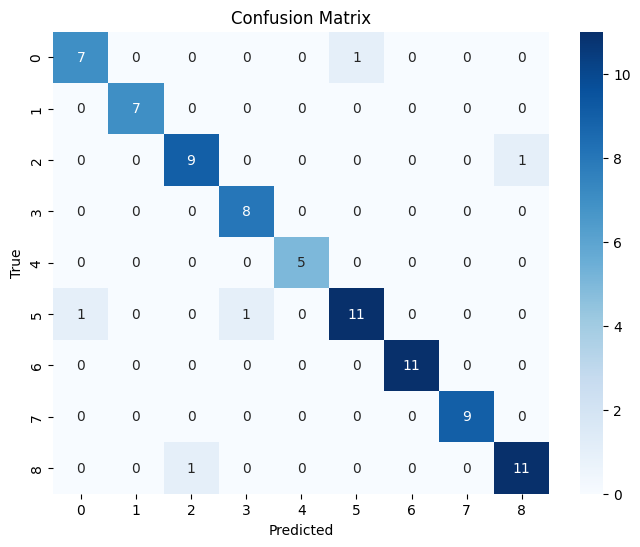

In [17]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    correct = 0
    total = 0
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        outputs = model(sequences)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total:.2f}%')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()